# Phase 2 — Lien climat–CO2 à l'échelle globale (2.5° × 2.5°)

**Projet Climat & CO2 — Migration R → Python**

Ce notebook synthétise les phases **2 à 4** : caractérisation statistique de 18 variables
climatiques (+ 3 Cloud Radiative Effects) issues des réanalyses **NCAR CFSR/CFSv2**, et
étude de leur lien avec le CO2 NOAA. La résolution 2.5° donne 144×73 = 10 512 pixels,
moyennés par cos(latitude) pour produire **une série mensuelle globale par variable**.

Pipeline complet : `scripts/phase2_climat_25/02_global_means.py` → `13_phase3_homog_comparison.py`.

## 1. Question scientifique

> **Les variations interannuelles du climat sont-elles liées au CO2 au-delà
> de la tendance commune, et dans quel sens (climat → CO2 ou CO2 → climat) ?**

Trois questions méthodologiques sous-jacentes :
* Comment **séparer** le signal de tendance commune (séculaire) du signal
  interannuel propre ?
* Quelles variables sont **corrélées spuriously** (uniquement par la trend) vs
  réellement liées au CO2 ?
* La transition modèle **CFSR → CFSv2 (jan 2011)** introduit-elle des artefacts
  systématiques dans les conclusions ?

## 2. Données utilisées

| Variable | Famille | Niveau |
|---|---|---|
| T2m, T500 | Thermo | 2 m, 500 hPa |
| SPFH2m, PWAT, APCP | Hydro | 2 m, colonne, surface |
| TCDC | Nuages | colonne |
| DLWRF, ULWRF, DSWRF, USWRF | Flux radiatifs all-sky | surface |
| CSDLF, CSULF, CSDSF, CSUSF | Flux clear-sky | surface |
| PRMSL, CDUVB, DUVB, ALBDO | Autres | divers |
| **CRE_SW, CRE_LW, CRE_net** | Dérivés | (all-sky − clear-sky) |

**Source** : 564 fichiers NetCDF mensuels 1979-01 → 2025-12, résolution 2.5° × 2.5°.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from climat import config
from climat.plots import setup_theme
setup_theme()

OUT = config.OUT_PHASE2
clim = pd.read_csv(OUT / 'climate_co2_monthly.csv', parse_dates=['date'])
trends = pd.read_csv(OUT / 'trends_summary.csv')
synth = pd.read_csv(OUT / 'synthese_finale.csv')
granger = pd.read_csv(OUT / 'granger_results.csv')
jumps = pd.read_csv(OUT / 'cfsr_to_cfsv2_jumps.csv')
cmp_homog = pd.read_csv(OUT / 'comparison_homog_correlations.csv')

print(f"climate_co2_monthly : {clim.shape}")
print(f"trends_summary     : {trends.shape}")
print(f"synthese_finale    : {synth.shape}")

climate_co2_monthly : (564, 26)
trends_summary     : (21, 10)
synthese_finale    : (21, 11)


## 3. Méthodes principales

**5 représentations temporelles** systématiquement comparées :

| Représentation | Calcul | Capture |
|---|---|---|
| `level` | brut | trend séculaire dominante |
| `anom`  | level − climato mensuelle | trend conservée, saison retirée |
| `resid` | anom − fit linéaire(t) | **signal interannuel pur** |
| `d1`    | $X_t - X_{t-1}$ | saisonnalité forte |
| `d12`   | $X_t - X_{t-12}$ | taux annuel de croissance |

**Tests statistiques** :
* **Mann-Kendall + Sen + bootstrap** (R=500) sur chaque variable.
* **OLS multivarié** + sélection **stepwise AIC backward**.
* **LassoCV** (10 plis) pour régularisation.
* **Granger** (lag 6 mois) sur les résidus et le d12.
* **Homogénéisation** : modèle additif $y = a + b \cdot t + c \cdot \mathbb{1}_{t \geq 2011} + \text{season}(t)$.

## 4. Résultats — Tendances 47 ans (Sen + bootstrap)

16 variables sur 21 ont une **tendance significative** (Mann-Kendall p < 0.05) :

Tendances significatives : 16 / 21

Top 5 plus rapides en %/an :
   var  sen_per_year  pct_per_year  mk_pvalue
  PWAT        0.0522        0.2115        0.0
  TCDC        0.1173        0.1939        0.0
CRE_LW       -0.0481       -0.1897        0.0
CRE_SW        0.0761       -0.1687        0.0
  APCP        0.0008        0.1471        0.0


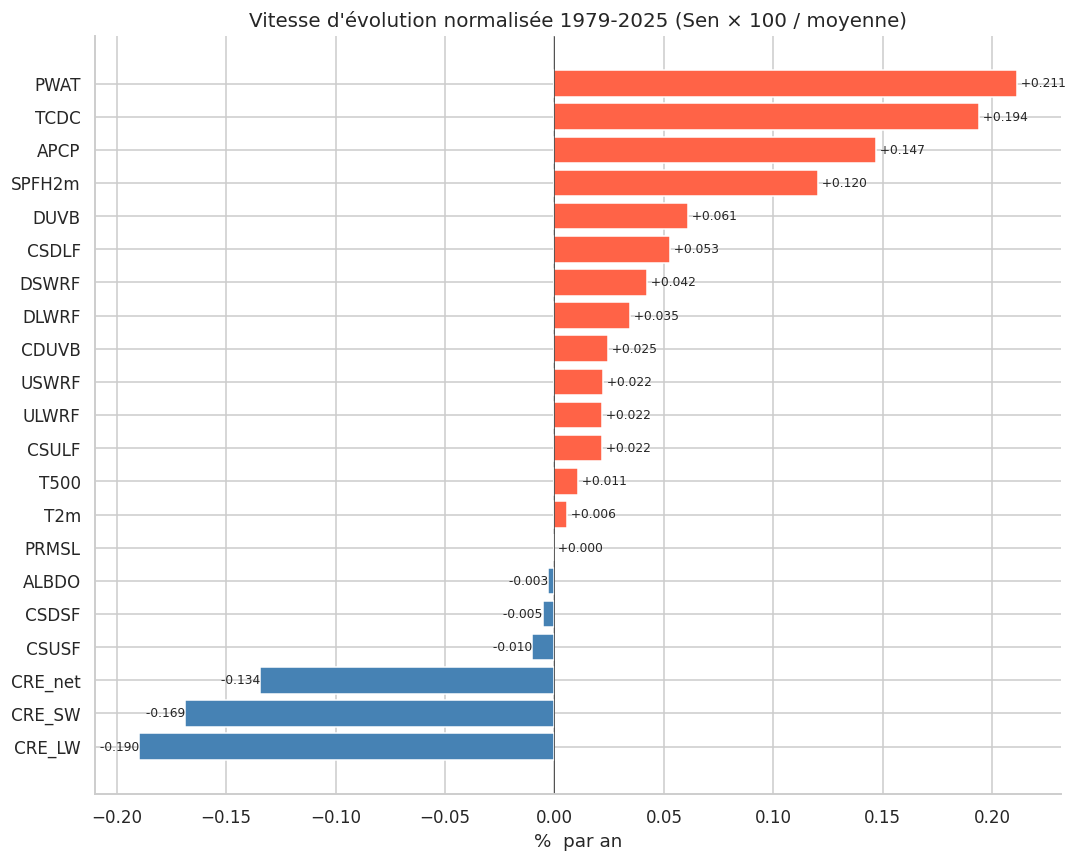

In [2]:
trends_sig = trends.copy()
trends_sig['significant'] = trends_sig['mk_pvalue'] < 0.05
trends_sig['pct_per_year'] = trends_sig['sen_per_year'] / trends_sig['mean'] * 100
trends_sig = trends_sig.sort_values('pct_per_year')
print(f"Tendances significatives : {int(trends_sig['significant'].sum())} / {len(trends_sig)}")
print(f"\nTop 5 plus rapides en %/an :")
print(trends_sig.assign(abs_pct=trends_sig['pct_per_year'].abs())
      .sort_values('abs_pct', ascending=False)
      .head(5)[['var', 'sen_per_year', 'pct_per_year', 'mk_pvalue']].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > 0 else 'steelblue' for v in trends_sig['pct_per_year']]
ax.barh(trends_sig['var'], trends_sig['pct_per_year'], color=colors)
for i, v in enumerate(trends_sig['pct_per_year']):
    ax.text(v, i, f' {v:+.3f}',
            ha='left' if v > 0 else 'right', va='center', fontsize=8)
ax.axvline(0, color='black', lw=0.4)
ax.set_xlabel('%  par an')
ax.set_title('Vitesse d\'évolution normalisée 1979-2025 (Sen × 100 / moyenne)')
fig.tight_layout()

**Conclusions §4** :
* **T2m global +0.78 K** sur 47 ans (Sen 0.0167 K/an).
* **CSDLF +7.84 W/m²** sur 47 ans : signature directe du **forçage GES** (effet de serre LW ciel clair).
* **PWAT +0.21 %/an** : humidification globale conforme à Clausius-Clapeyron (~7%/K).
* **TCDC +0.19 %/an** (avec saut algorithmique CFSR/CFSv2).
* **CRE_LW −0.19 %/an, CRE_SW −0.17 %/an** : perte d'effet refroidissant des nuages SW + perte d'effet réchauffant LW.

## 5. Corrélations climat–CO2 — le piège des tendances communes

**Cas d'école** : sur les **niveaux bruts**, beaucoup de variables ont une corrélation
très forte avec le CO2 (r > 0.5) simplement parce qu'elles partagent une tendance commune.
Le détendrement révèle un signal **beaucoup plus modeste**.

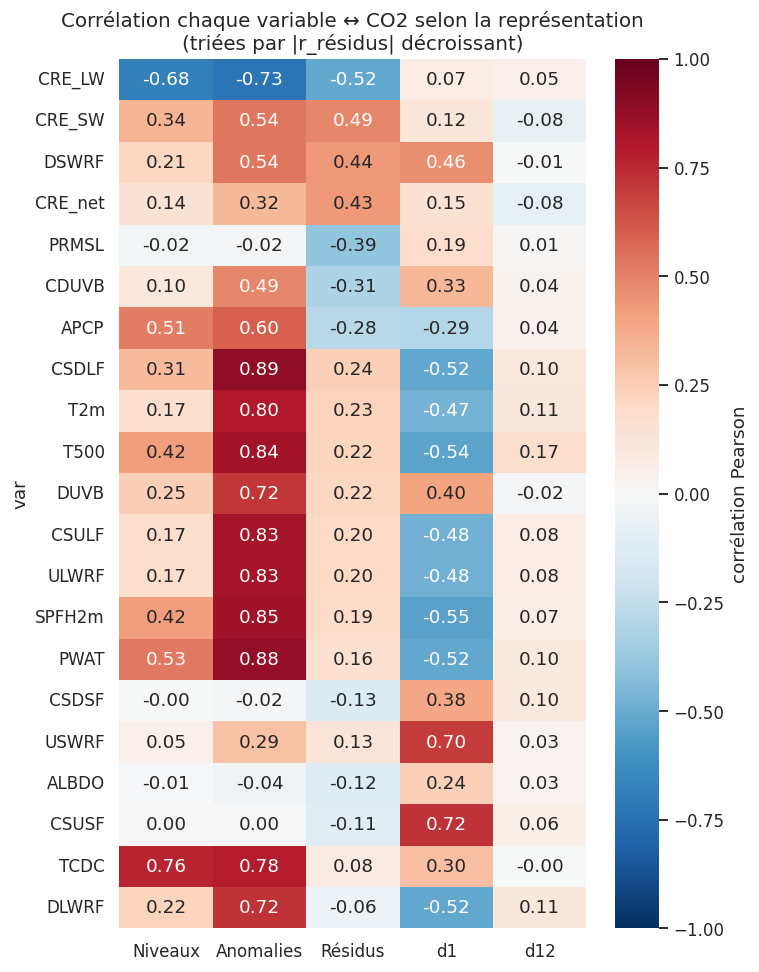

In [3]:
# Heatmap des 5 représentations
synth_plot = synth.set_index('var')[['r_level', 'r_anom', 'r_resid', 'r_d1', 'r_d12']]
synth_plot.columns = ['Niveaux', 'Anomalies', 'Résidus', 'd1', 'd12']
synth_plot = synth_plot.sort_values('Résidus', key=lambda c: c.abs(), ascending=False)

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(synth_plot, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'corrélation Pearson'})
ax.set_title('Corrélation chaque variable ↔ CO2 selon la représentation\n'
             '(triées par |r_résidus| décroissant)')
fig.tight_layout()

In [4]:
# Combien de variables "spurious" ?
n_spurious = int((synth['spurious_trend'] == 'OUI').sum())
print(f"Variables \"spurious\" (|r_anom| > 0.5 mais |r_resid| < 0.25) : {n_spurious}/{len(synth)}")

print("\nTop 5 corrélations sur résidus (signal interannuel pur) :")
print(synth.head(5)[['var', 'r_resid', 'sens_d12']].round(3).to_string(index=False))

Variables "spurious" (|r_anom| > 0.5 mais |r_resid| < 0.25) : 10/21

Top 5 corrélations sur résidus (signal interannuel pur) :
    var  r_resid sens_d12
 CRE_LW   -0.523 X -> CO2
 CRE_SW    0.489    aucun
  DSWRF    0.437    aucun
CRE_net    0.432 CO2 -> X
  PRMSL   -0.394 X -> CO2


**Conclusions §5** :
* **10 variables sur 21** sont *spurious* : forte corrélation sur niveaux,
  presque nulle sur résidus.
* À l'échelle interannuelle, seules **5 variables** ont |r| > 0.3 sur résidus :
  CRE_LW (−0.52), CRE_SW (+0.49), DSWRF (+0.44), CRE_net (+0.43), PRMSL (−0.39).
* Les **CRE** sont les variables qui réagissent le plus à l'ENSO (modulation
  des nuages tropicaux), ce qui explique leur forte corrélation interannuelle
  avec le CO2 (lui-même ENSO-sensible).

## 6. Causalité de Granger climat → CO2

**Test** : la connaissance des **6 derniers mois** d'une variable climatique
X aide-t-elle à prédire le CO2 mieux que la connaissance des 6 derniers mois
du CO2 seul ?

On teste sur la représentation **d12** (taux annuel) qui est stationnaire.

Sur d12 (lag 6 mois) :
  Variables X → CO2 (p<0.05) : 15/21
  Variables CO2 → X (p<0.05) : 8/21
  → sens dominant : climat → CO2 (1.9× plus)


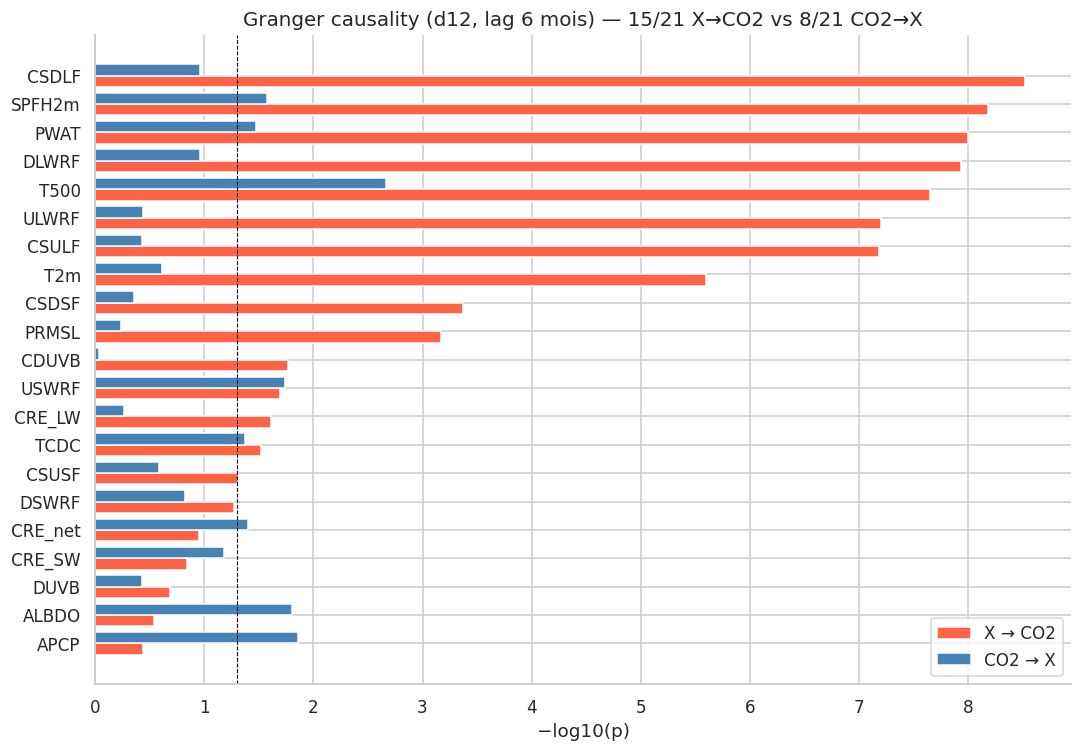

In [5]:
gr_d12 = granger.query("repr == 'd12'").sort_values('p_x_to_co2')
n_x_to_co2 = int(((gr_d12['p_x_to_co2'] < 0.05)).sum())
n_co2_to_x = int(((gr_d12['p_co2_to_x'] < 0.05)).sum())
print(f"Sur d12 (lag 6 mois) :")
print(f"  Variables X → CO2 (p<0.05) : {n_x_to_co2}/21")
print(f"  Variables CO2 → X (p<0.05) : {n_co2_to_x}/21")
print(f"  → sens dominant : climat → CO2 ({n_x_to_co2/n_co2_to_x:.1f}× plus)")

fig, ax = plt.subplots(figsize=(10, 7))
df_plot = gr_d12.copy()
df_plot['nlogp_x_to_co2'] = -np.log10(df_plot['p_x_to_co2'].clip(lower=1e-300))
df_plot['nlogp_co2_to_x'] = -np.log10(df_plot['p_co2_to_x'].clip(lower=1e-300))
order = df_plot.sort_values('nlogp_x_to_co2')['var'].tolist()
y_pos = np.arange(len(order))
w = 0.4
for i, v in enumerate(order):
    row = df_plot[df_plot['var'] == v].iloc[0]
    ax.barh(i - w/2, row['nlogp_x_to_co2'], height=w, color='tomato',
            label='X → CO2' if i == 0 else None)
    ax.barh(i + w/2, row['nlogp_co2_to_x'], height=w, color='steelblue',
            label='CO2 → X' if i == 0 else None)
ax.axvline(-np.log10(0.05), ls='--', color='black', lw=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels(order)
ax.set_xlabel('−log10(p)')
ax.set_title(f'Granger causality (d12, lag 6 mois) — {n_x_to_co2}/21 X→CO2 vs {n_co2_to_x}/21 CO2→X')
ax.legend()
fig.tight_layout()

**Conclusions §6** :
* À l'échelle **interannuelle**, le climat **précède** le CO2 de 6 mois
  pour 15 variables sur 21 → **carbon cycle response** : ENSO chauffe → stress
  hydrique forêts → respiration > photosynthèse → CO2 atmosphérique augmente.
* Le sens inverse (CO2 → climat, par exemple via effet de serre direct) n'est
  significatif que sur 8 variables et **avec un délai > 6 mois** (effet plus lent).
* Ces résultats sont **cohérents** avec la phase 1 (ENSO lag 6 mois sur le
  taux annuel CO2).

## 7. Régression multivariée — R² = 0.748 sur 12 prédicteurs

**OLS multivariée sur les résidus**, suivie de sélection **stepwise AIC backward** :

In [6]:
# Re-fait la régression rapidement (mais on a déjà les conclusions dans regression_summary.txt)
import pickle
import statsmodels.api as sm
from scipy.linalg import qr

with open(OUT / 'series_transformed.pkl', 'rb') as fh:
    ds = pickle.load(fh)

clim_vars = config.CLIM_VARS + ['CRE_SW', 'CRE_LW', 'CRE_net']
X = ds['resid'][clim_vars]
y = ds['resid']['co2_trend'].to_numpy()

# Retire les colonnes redondantes (mimique R lm())
Q, R, piv = qr(X.to_numpy(dtype=float), mode='economic', pivoting=True)
diag = np.abs(np.diag(R))
rank = int(np.sum(diag > 1e-9 * diag.max()))
aliased = [X.columns[i] for i in piv[rank:]]
X_clean = X.drop(columns=aliased)

fit_full = sm.OLS(y, sm.add_constant(X_clean)).fit()
print(f"Colonnes aliasées retirées : {aliased}")
print(f"R² complet : {fit_full.rsquared:.3f}   |   {X_clean.shape[1]} prédicteurs")
print(f"Adj. R² : {fit_full.rsquared_adj:.3f}")

Colonnes aliasées retirées : ['ULWRF', 'USWRF', 'CRE_LW']
R² complet : 0.750   |   18 prédicteurs
Adj. R² : 0.741


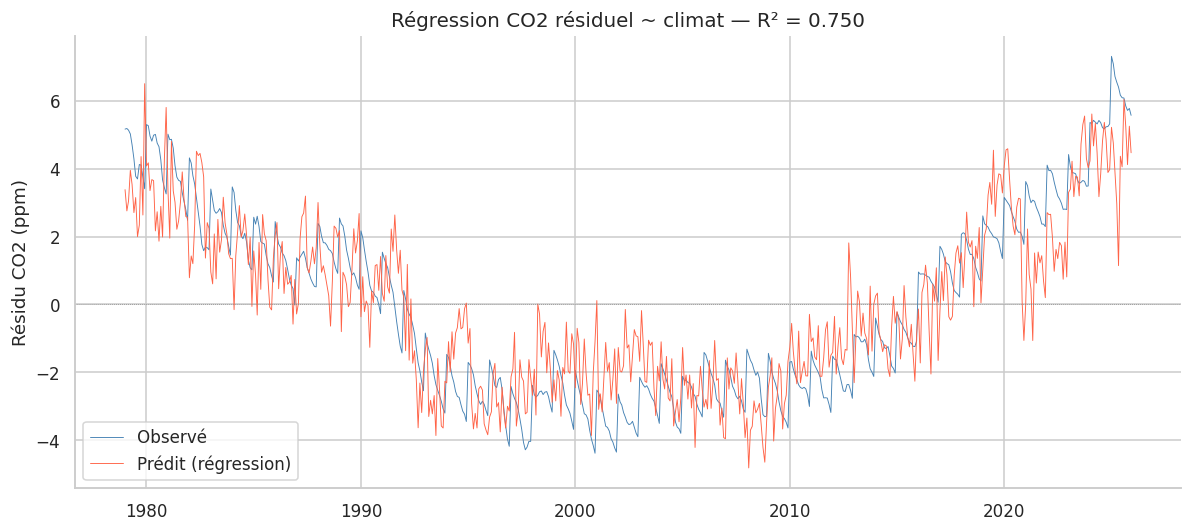

In [7]:
# Plot observé vs prédit
fitted = fit_full.fittedvalues
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ds['resid']['date'], y, color='steelblue', lw=0.6, label='Observé')
ax.plot(ds['resid']['date'], fitted, color='tomato', lw=0.6, label='Prédit (régression)')
ax.axhline(0, ls=':', color='grey', lw=0.5)
ax.set_ylabel('Résidu CO2 (ppm)')
ax.set_title(f'Régression CO2 résiduel ~ climat — R² = {fit_full.rsquared:.3f}')
ax.legend()
fig.tight_layout()

## 8. Saut CFSR → CFSv2 (jan 2011) — biais méthodologique

Le changement de réanalyse en jan 2011 (CFSR → CFSv2) introduit un **saut de
niveau** dans 17 variables sur 21. Quantification par un modèle
$y = a + b \cdot t + c \cdot \mathbb{1}_{t \geq 2011} + \text{season}$.

Top 5 plus gros sauts (en écart-type de la variable) :
    var  jump_pct  jump_in_sd  p_value  significant
 CRE_LW    -8.022      -1.922      0.0         True
  PRMSL    -0.026      -1.772      0.0         True
 CRE_SW   -11.389       1.564      0.0         True
   TCDC     4.347       1.140      0.0         True
CRE_net   -15.720       1.126      0.0         True

Variables avec saut significatif (p<0.05) : 17 / 21


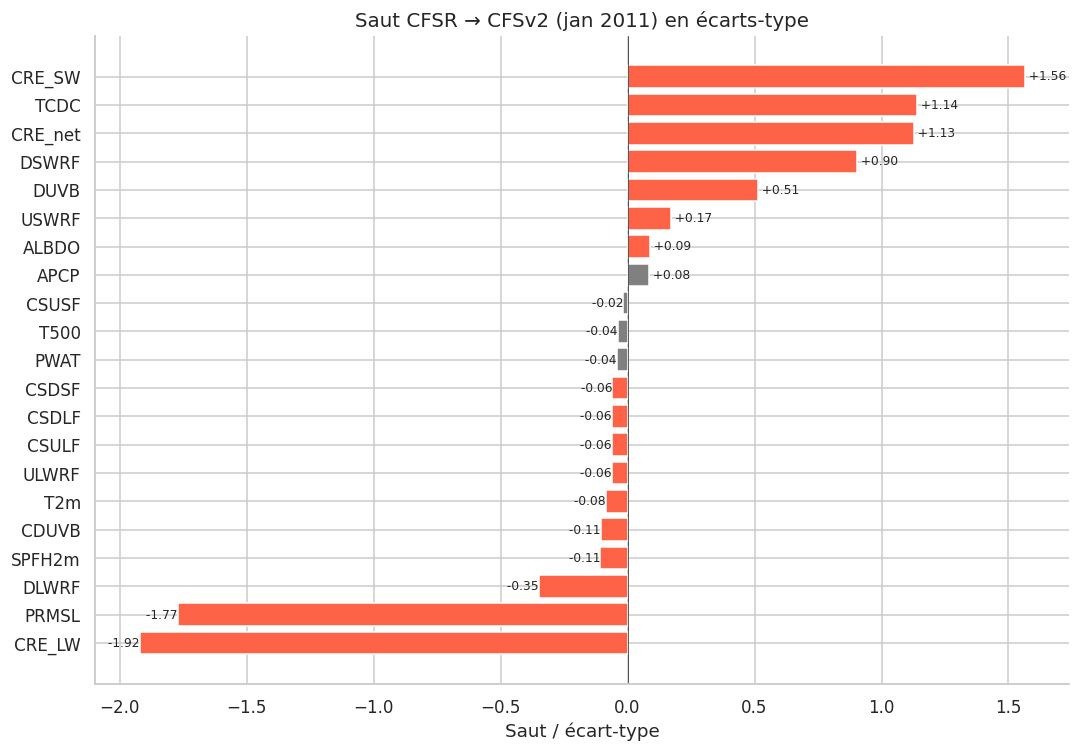

In [8]:
j = jumps.copy().sort_values('jump_in_sd', key=lambda s: s.abs(), ascending=False)
print("Top 5 plus gros sauts (en écart-type de la variable) :")
print(j[['var', 'jump_pct', 'jump_in_sd', 'p_value', 'significant']]
      .head(5).round(3).to_string(index=False))
n_sig = int(j['significant'].sum())
print(f"\nVariables avec saut significatif (p<0.05) : {n_sig} / {len(j)}")

fig, ax = plt.subplots(figsize=(10, 7))
j_sorted = jumps.sort_values('jump_in_sd')
colors = ['tomato' if s else 'grey' for s in j_sorted['significant']]
ax.barh(j_sorted['var'], j_sorted['jump_in_sd'], color=colors)
for i, v in enumerate(j_sorted['jump_in_sd']):
    ax.text(v, i, f' {v:+.2f}', ha='left' if v > 0 else 'right', va='center', fontsize=8)
ax.axvline(0, color='black', lw=0.4)
ax.set_xlabel('Saut / écart-type')
ax.set_title('Saut CFSR → CFSv2 (jan 2011) en écarts-type')
fig.tight_layout()

In [9]:
# Impact sur les corrélations
print("=== Variables où le saut CFSR/CFSv2 modifie LE PLUS la corrélation au CO2 ===")
print(cmp_homog.head(10).round(3).to_string(index=False))

=== Variables où le saut CFSR/CFSv2 modifie LE PLUS la corrélation au CO2 ===
    var  brute  homog   diff
 CRE_SW  0.489  0.046 -0.443
 CRE_LW -0.523 -0.094  0.429
  DSWRF  0.437  0.012 -0.425
CRE_net  0.432  0.014 -0.418
   DUVB  0.218 -0.148 -0.366
  PRMSL -0.394 -0.043  0.351
   TCDC  0.080 -0.267 -0.347
  DLWRF -0.056  0.251  0.307
  USWRF  0.130 -0.055 -0.185
    T2m  0.233  0.352  0.119


**Conclusions §8** : 
* L'homogénéisation **détruit** beaucoup de corrélations apparentes (CRE_SW, CRE_LW,
  DSWRF, CRE_net, DUVB) — c'était surtout le saut technique qui les portait.
* L'homogénéisation **renforce** par contre la corrélation de **T2m, CSDLF, ULWRF**
  → ces variables portent un **signal climatique réel** masqué par le saut.
* R² du modèle multivarié passe de **0.75 → 0.44** après homogénéisation :
  un tiers de la variance "climat-CO2" était portée par cet artefact technique.

## 9. Synthèse et regard critique

### Résultats robustes
* **T2m global +0.78 K**, **CSDLF +7.84 W/m²** en 47 ans → signature GES confirmée.
* **10/21 variables "spurious"** : il faut systématiquement détendre avant analyse interannuelle.
* **15/21 X→CO2** Granger sig. à lag 6 mois → carbon cycle response dominante.
* **R² stepwise = 0.747** avec 12 prédicteurs sur le signal interannuel.

### Limites identifiées
1. **Détendrage linéaire** alors que la trend CO2 est cubique → légère courbure résiduelle.
2. **Sauts CFSR/CFSv2** : l'homogénéisation par modèle additif corrige le **niveau** mais
   pas la **variance** (les CRE restent plus bruyants après 2011).
3. **Échelle globale uniquement** : les puits/sources tropicaux (Amazonie, Indonésie)
   sont noyés dans la moyenne — voir **phase 5** pour l'analyse régionale.

### Pour aller plus loin
* **Phase 5** (`04_phase3_climat_05.ipynb`) : distribution spatiale du réchauffement,
  cartes pixel-par-pixel, hotspots régionaux.